In [67]:
from warnings import simplefilter
from pathlib import Path
from itertools import product

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import kpss, adfuller, seasonal_decompose, STL
from statsmodels.tools.eval_measures import rmse, rmspe
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf
from sklearn.metrics import mean_absolute_percentage_error as mape

simplefilter('ignore')
plt.rcParams["figure.figsize"] = (12,4)

In this, we will cover the following recipes:

• Plotting ACF and PACF

• Forecasting univariate time series data with exponential smoothing

• Forecasting univariate time series data with non-seasonal ARIMA

• Forecasting univariate time series data with seasonal ARIMA

In [68]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch10')

life = pd.read_csv(path / 'life_expectancy_birth.csv', index_col='year', parse_dates=True, skipfooter=1)
milk = pd.read_csv(path / 'milk_production.csv', index_col='month', parse_dates=True)

life.head()

,value
year,
1960-01-01,69.123902
1961-01-01,69.760244
1962-01-01,69.149756
1963-01-01,69.248049
1964-01-01,70.311707


In [69]:
milk.head()

,production
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


<Axes: title={'center': 'Monthly Milk Production'}, xlabel='month'>

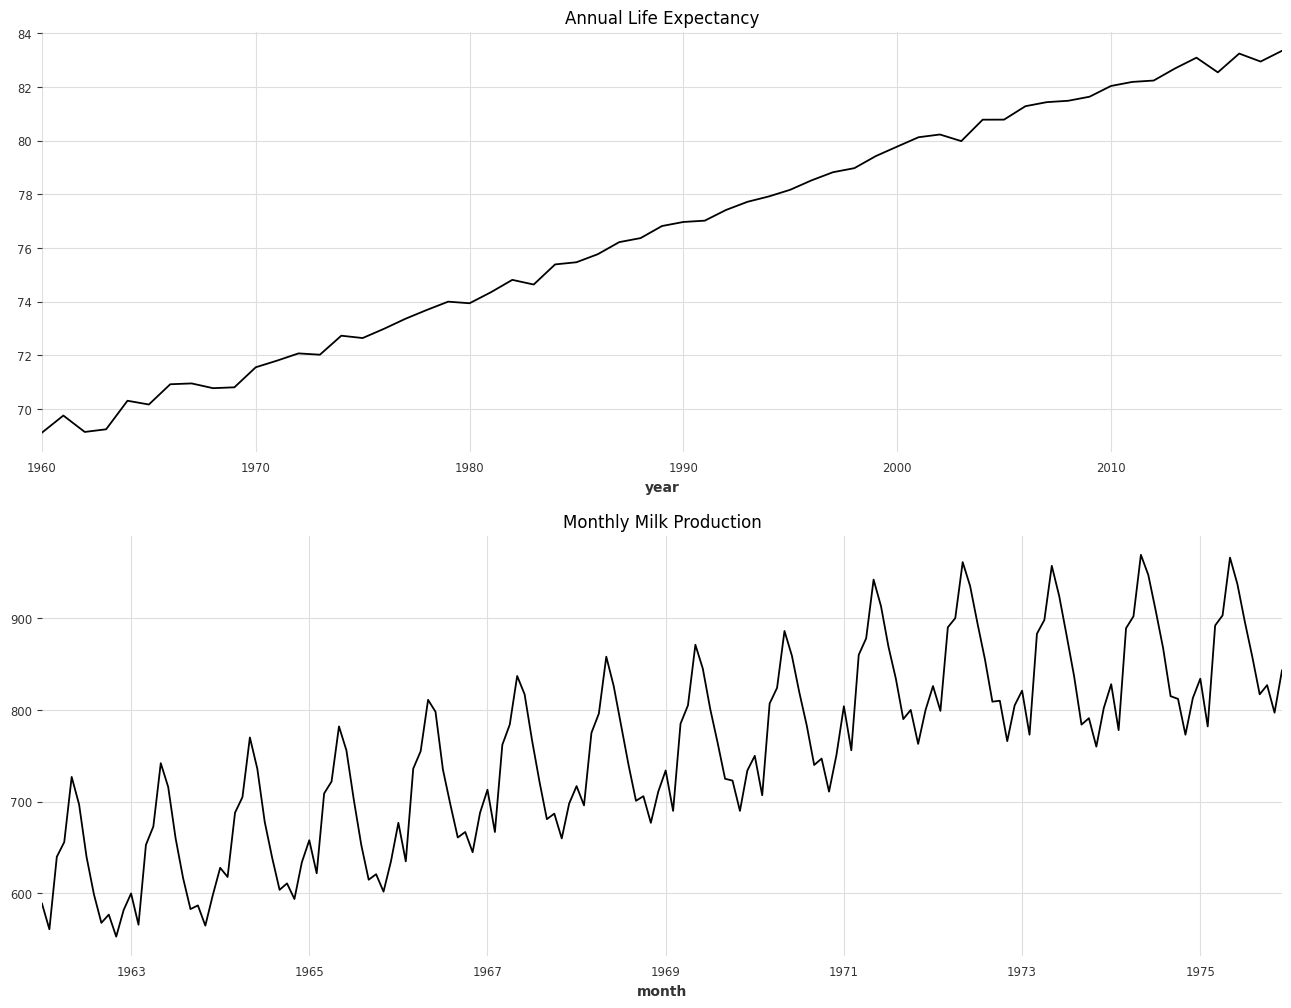

In [70]:
fig, ax = plt.subplots(2, 1, figsize=(16, 12))
life.plot(title='Annual Life Expectancy', legend=False, ax=ax[0])
milk.plot(title="Monthly Milk Production", legend=False, ax=ax[1])

In [71]:
# Create a generalized function, split_data, which splits the data based on a test split factor.
def split_data(data, test_split):
    '''
    data: dataframe
    test_plit: the size for splitting the dataframe
    '''
    l = len(data)
    t_idx = round(l*(1-test_split))
    train, test = data[: t_idx], data[t_idx :]
    print(f'train: {len(train)}, test: {len(test)}')

    return train, test

In [72]:
test_split = 0.15
milk_train, milk_test = split_data(milk, test_split)
life_train, life_test = split_data(life, test_split)

train: 143, test: 25
train: 50, test: 9


In [73]:
# Check stationarity using Dickey Fuller
def check_stationarity(data):
    '''
    data: dataframe
    '''
    results = adfuller(data)[1:3]
    s = 'Non-Stationary'
    if results[0] < 0.05:
        s = 'Stationary'

    print(f'"{s} \t P-value: {results[0]} \t lags: {results[1]}')

    return {s, results[0]}

The get_best_model function will compare the different models – for example, ARIMA models – to select the best model and the set of parameters associated with that model. The get_best_model function will take a dictionary that contains the produced model, parameters used, and the scores for each model.

The function will return the winning model based on a scoring (metric) criterion
of your choice. This is the c parameter of the function, which defaults to AIC. For
instance, you may choose the evaluation (the c parameter) to be based on the **Root**
**Mean Squared Percentage Error** (**RMSPE**), **Root Mean Square Error** (**RMSE**),
**Mean Square Error** (**MSE**), **Akaike's Information Criteria** (**AIC**), **Corrected**
**Akaike's Information Criteria** (**AICc**), and **Bayesian Information Criteria** (**BIC**),

In [74]:
# Hyperparameter tuning
def get_best_model(score, c='AIC'):
    '''
    score: scores for each model
    c: scoring (metric) criterion
    '''
    initial_score = score[0][c]
    best_model = 0
    for k, v in score.items():
        if v[c] < initial_score:
            initial_score = v[c]
            best_model = k
    
    print(f'Best model: {best_model} with lowest {c} score: {initial_score}')

    return score[best_model]['model']

In [115]:
# Plot forecast function

def plot_forecast(model, start, train, test):
    """
    Plots the forecast for a given ARIMA model, handling both fitted and unfitted models.

    Parameters:
    model: ARIMA or fitted ARIMA model object
    start: Starting position for plotting (e.g., a date or index)
    train: Training dataset (time series)
    test: Testing dataset (time series)
    """
    # Check if the model is already fitted
    if not hasattr(model, 'params'):
        # Fit the model if it's not already fitted
        model = model.fit()

    # Generate predictions
    forecast_values = model.predict(start=len(train), end=len(train) + len(test) - 1)

    # Create a DataFrame for the forecast to align it with test data
    forecast = pd.DataFrame(forecast_values, index=test.index, columns=['Forecast'])

    # Plot the train, test, and forecast data
    ax = train.loc[start:].plot(style='--', label='Train Data', figsize=(10, 6))
    test.plot(ax=ax, label='Test Data', color='orange')
    forecast.plot(ax=ax, style='-', label='Forecast', color='green')

    # Add labels and legend
    ax.set_title("Train, Test, and Forecast Plot")
    ax.set_xlabel("Time")
    ax.set_ylabel("Values")
    ax.legend()
    return ax


# def plot_forecast(model, start, train, test):
#     '''
#     model: model object that you have trained
#     start: starting position
#     train: train set
#     test: test set
#     '''
#     # forecast = pd.DataFrame(model.forecast(test.shape[0]), index=test.index)
#     forecast_values = model.predict(start=len(train), end=len(train) + len(test) - 1)
#     forecast = pd.DataFrame(forecast_values, index=test.index)
#     ax = train.loc[start:].plot(style='--')
#     test.plot(ax=ax)
#     forecast.plot(ax=ax, style='-.')
#     ax.legend(['origin_train', 'origin_test', 'forecast'])
#     plt.show()

# def plot_forecast(model, start, train, test):
#     '''
#     model: Fitted model object
#     start: Starting position for plotting
#     train: Train dataset (time series)
#     test: Test dataset (time series)
#     '''
#     # Ensure the model is fitted
#     # model_fit = model.fit()

#     # Generate predictions
#     forecast_values = model.predict(start=len(train), end=len(train) + len(test) - 1)
#     forecast = pd.DataFrame(forecast_values, index=test.index)

#     # Plot the train and test data
#     ax = train.loc[start:].plot(style='--', label='Train Data')
#     test.plot(ax=ax, label='Test Data')

#     # Plot the forecast
#     forecast.plot(ax=ax, style='-', label='Forecast')

#     ax.legend()
    
#     return ax

Create a combinator utility function that takes a list of parameter values and returns a Cartesian product of these choices. You will use this when performing a grid search for hyperparameter tuning. In grid search, you specify a combination of parameter values to train multiple models on each set and then evaluate the winning model using the get_best_model function. For example, suppose your list contains three possible values for three different parameters. In such a case, the combinator function will return a list containing 3x3 or nine possible combinations.

In [116]:
# Utility function that takes a list of parameter values and return a Cartesian Product of these choices.
def combinator(items):
    '''
    items: 
    '''
    combo = [i for i in product(*items)]
    return combo

### Plotting ACF and PACF

An ARMA(p, q) model usually assumes stationarity. This combines Autogressive, AR(p) and Moving Average, MA(q) models. The core idea behind these models is built on the assumption that the current value of a particular variable, x , can be estimated from past values of itself. For example, in an autoregressive model of order p or AR(p), we assume that the current value, x𝑡 , at time 𝑡 can be estimated from its past values ( x𝑡−1 , x𝑡−2 , … , x𝑡−p ) up to p, where p determines how many lags (steps back) we need to go. If p=2 , this means we must use two previous periods (x(𝑡−1) , x(𝑡−2) ) to predict x𝑡 . Depending on the granularity of your time series data, p=2 can be 2 hours, 2 days, 2 months, or 2 quarters. To build an ARMA model, you will need to provide values for the p and q orders (known as lags). These are considered hyperparameters since they are supplied by you to influence the model.

Now how to find the appropriate number of lags? This is where ACF and PACF plots come in handy. The ACF and PACF plots are used to check whether a time series process is an AR, MA, or ARMA process (if both are present) and significant values for p and q. The two plots are known as collelograms. 

The difference between an ARMA and ARIMA, written as ARIMA(p, d, q), is in the stationarity assumption. The d parameter in ARIMA is for the differencing order. An ARMA model assumes a stationary process, while an ARIMA model does not since it handles differencing. An ARIMA model is a more generalized model since it can satisfy an ARMA model by making the differencing factor d=0. Hence, ARIMA(1,0,1) is ARMA(1,1).

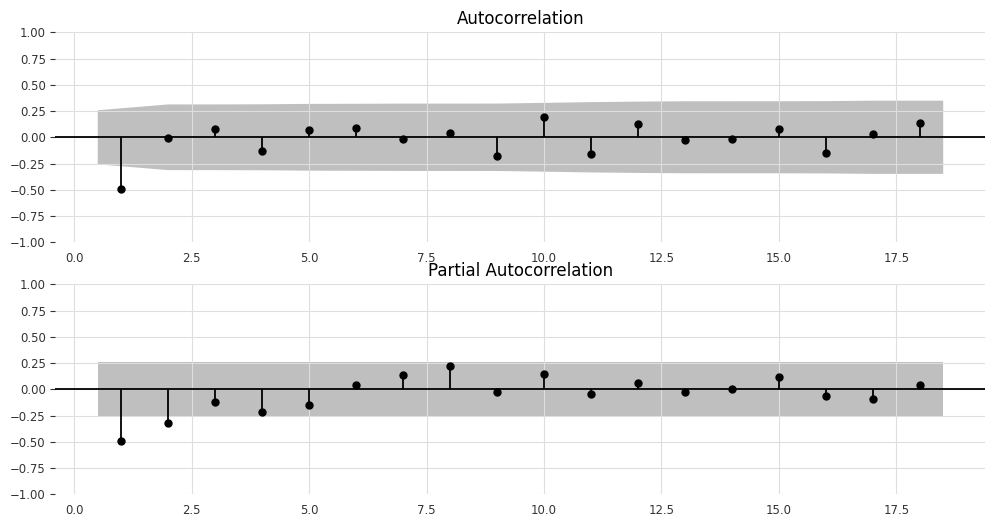

In [117]:
life_diff = life.diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(12,6))
plot_acf(life_diff, zero=False, ax=ax[0])
plot_pacf(life_diff, zero=False, ax=ax[1])
plt.show()

The ACF plot shows a significant spike at lag (order) 1. Significance is represented when a lag (vertical line) goes above or below the shaded area. The shaded area represents the confidence interval, which is set to 95% by default. In the ACF plot, only the first lag is significant, which is below the lower confidence interval, and then cuts off right after. All the remaining lags are not significant. This indicates a moving average of order one or MA(1).

The PACF plot shows a gradual decay with oscillation. Generally, if PACF shows a gradual decay, it indicates a moving average model. For example, if you are using an ARMA or ARIMA model, it would be represented as ARMA(0, 1) once the data has been differenced to make it stationary, or ARIMA(0, 1, 1), indicating a first-order differencing with d=1. In both ARMA and ARIMA, the AR order is p=0, and the MA order is q=1.

In [118]:
# Let's try for a complex dataset: Diffence it to make it stationary
milk_diff = milk.diff(12).dropna()

check_stationarity(milk_diff)

"Non-Stationary 	 P-value: 0.1607988052771125 	 lags: 12


{0.1607988052771125, 'Non-Stationary'}

The differenced time series is still not stationary, so you still need to perform a second differencing.

In [119]:
milk_diff_1 = milk.diff(12).diff(1).dropna()

check_stationarity(milk_diff_1)

"Stationary 	 P-value: 1.865423431878848e-05 	 lags: 11


{1.865423431878848e-05, 'Stationary'}

Great, now you have a stationary process.

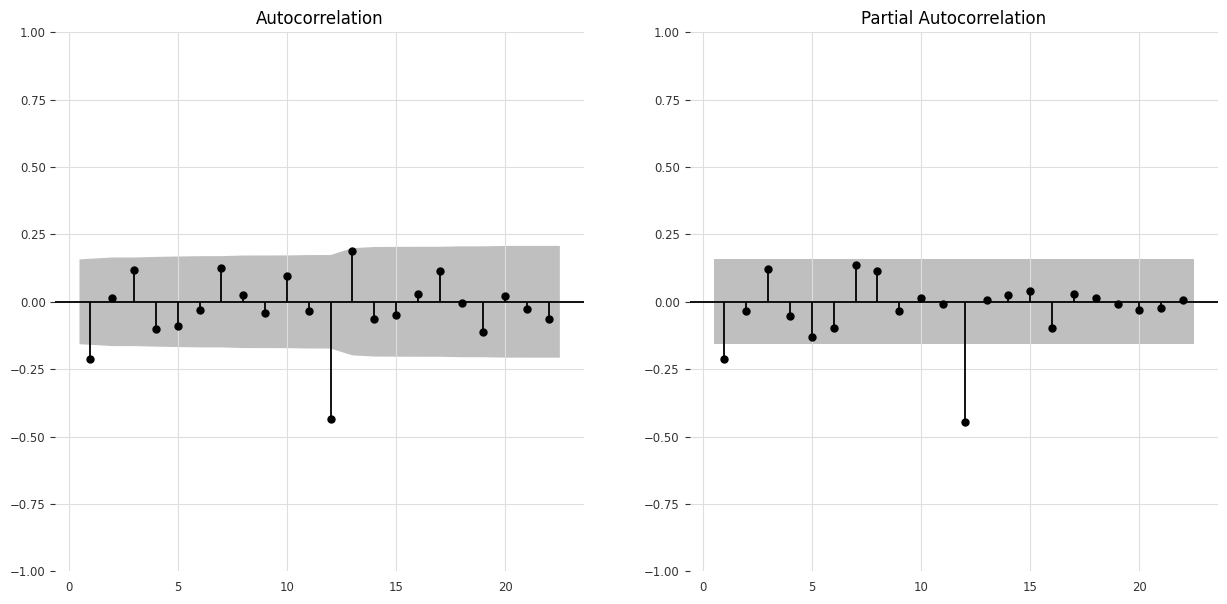

In [121]:
# Plot ACF and PACF for stationary time series in milk_diff_1
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plot_acf(milk_diff_1, zero=False, ax=ax[0]); plot_pacf(milk_diff_1, zero=False, ax=ax[1]); plt.show()

For the seasonal orders, P and Q, you should diagnose spikes or behaviors at lags s, 2s, 3s, and so on, where s is the number of periods in a season. For example, in the milk production data, s=12 (since there are 12 monthly periods in a season). Then, we observe for significance at 12 (s), 24 (2s), 36 (3s), and so on.

Starting with the ACF plot, there is a significant spike at lag 1, which represents the
non-seasonal order for the MA process as q=1. The spike at lag 12 represents the seasonal
order for the MA process as Q=1. Notice that there is a cut-off right after lag 1, then
a spike at lag 12, followed by a cut-off (no other significant lags afterward). These indicate
a moving average model: an MA(1) for the non-seasonal component and an MA(1) for
the seasonal component. The PACF plot confirms this as well; an exponential decay at lags
12, 24, and 36 indicates an MA model. So, the SARIMA model would be ARIMA
(0, 1,1)(0, 1, 1, 12).

----
Let's see how ACF plots can be used
to diagnose the model's residuals. Let's build the seasonal ARIMA model we identified earlier in this recipe as SARIMA(0,1,1)(0,1,1,12), then use the ACF to diagnose the residuals. If the model captured all the information that's been embedded within the time series, you would expect the residuals to have no autocorrelation:

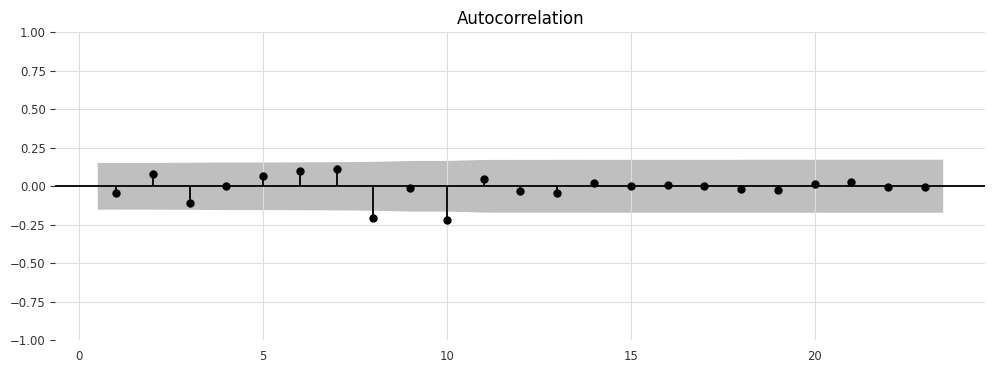

In [122]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(milk, order=(0,1,1), seasonal_order=(0,1,1,12)).fit(disp=False)
plot_acf(model.resid[1:], zero=False)
plt.show()

Overall, there are a couple of slightly significant lags, indicating the existence of some autocorrelation in the residuals. When the residuals show autocorrelation, this can mean that the model did not capture all the information, and there is potential for further improvement.

### Forecasting univariate time series data with exponential smoothing

In statsmodels, there are three different implementations (classes) of exponential smoothing, depending on the nature of the data you are working with:

• **SimpleExpSmoothing**: Simple exponential smoothing is used when the time series process lacks seasonality and trend. This is also referred to as single exponential smoothing.

• **Holt**: Holt's exponential smoothing is an enhancement of the simple exponential smoothing and is used when the time series process contains only trend (but no seasonality). It is referred to as double exponential smoothing.

• **ExponentialSmoothing**: Holt-Winters' exponential smoothing is an enhancement of Holt's exponential smoothing and is used when the time series process has both seasonality and trend. It is referred to as triple exponential smoothing.

In [123]:
from statsmodels.tsa.api import ExponentialSmoothing

In [124]:
trend = ['add', 'mul']
damped = [True, False]
life_ex_comb = combinator([trend, damped])
life_ex_comb

[('add', True), ('add', False), ('mul', True), ('mul', False)]

In [125]:
train = life_train.values.ravel()
y = life_test.values.ravel()
score = {}

for i, (t, dp) in enumerate(life_ex_comb):
    exp = ExponentialSmoothing(train, trend=t, damped_trend=dp, seasonal=None)
    model = exp.fit(use_brute=True, optimized=True)
    y_hat = model.forecast(len(y))
    score[i] = {
        'trend': t,
        'damped': dp,
        'AIC': model.aic,
        'BIC': model.bic,
        'AICc': model.aicc,
        'RMSPE': rmspe(y, y_hat),
        'RMSE': rmse(y, y_hat),
        'MAPE': mape(y, y_hat),
        'model': model
    }

In [126]:
life_best_model = get_best_model(score, 'AIC')

Best model: 1 with lowest AIC score: -137.03060180016485


In [127]:
life_best_model.summary()

Dep. Variable:,endog,No. Observations:,50
Model:,ExponentialSmoothing,SSE,2.749
Optimized:,True,AIC,-137.031
Trend:,Additive,BIC,-129.383
Seasonal:,None,AICC,-135.077
Seasonal Periods:,None,Date:,"Thu, 23 Jan 2025"
Box-Cox:,False,Time:,02:38:23
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.1621951,alpha,True
smoothing_trend,0.1621951,beta,True


Notice that the optimal 𝛼 and 𝛽 values have been deduced.

<Axes: title={'center': 'Train, Test, and Forecast Plot'}, xlabel='Time', ylabel='Values'>

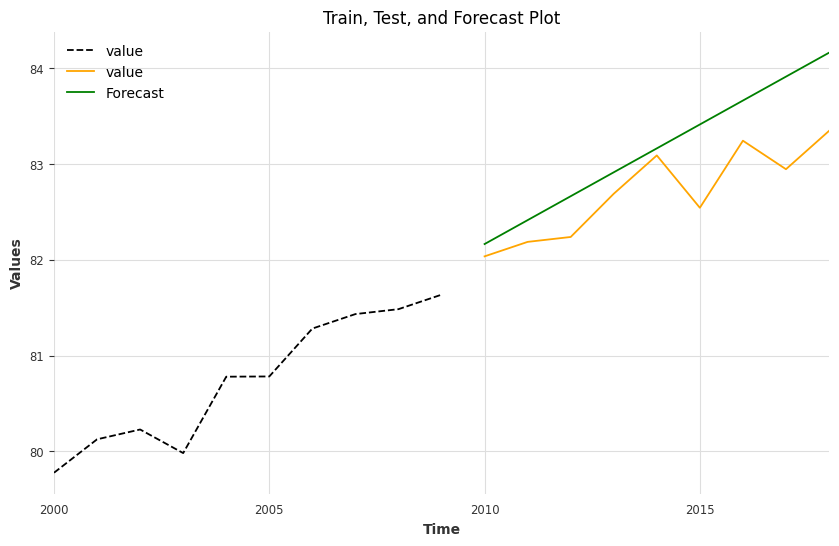

In [128]:
plot_forecast(life_best_model, '2000', life_train, life_test)

In [129]:
trend, damped = ['add', 'mul'], [True, False]
seasonal, periods = ['add', 'mul'], [4, 6, 12]
milk_exp_comb = combinator([trend, damped, seasonal, periods])
milk_exp_comb

[('add', True, 'add', 4),
 ('add', True, 'add', 6),
 ('add', True, 'add', 12),
 ('add', True, 'mul', 4),
 ('add', True, 'mul', 6),
 ('add', True, 'mul', 12),
 ('add', False, 'add', 4),
 ('add', False, 'add', 6),
 ('add', False, 'add', 12),
 ('add', False, 'mul', 4),
 ('add', False, 'mul', 6),
 ('add', False, 'mul', 12),
 ('mul', True, 'add', 4),
 ('mul', True, 'add', 6),
 ('mul', True, 'add', 12),
 ('mul', True, 'mul', 4),
 ('mul', True, 'mul', 6),
 ('mul', True, 'mul', 12),
 ('mul', False, 'add', 4),
 ('mul', False, 'add', 6),
 ('mul', False, 'add', 12),
 ('mul', False, 'mul', 4),
 ('mul', False, 'mul', 6),
 ('mul', False, 'mul', 12)]

In [130]:
train = milk_train.values.ravel()
y = milk_test.values.ravel()
milk_scores = {}
for i, (t, dp, s, sp) in enumerate(milk_exp_comb):
    exp = ExponentialSmoothing(train, trend=t, damped_trend=dp, seasonal=s, seasonal_periods=sp)
    model = exp.fit(use_brute=True, optimized=True)
    y_hat = model.forecast(len(y))
    milk_scores[i] = {
        'trend': t,
        'damped': dp,
        'AIC': model.aic,
        'BIC': model.bic,
        'AICc': model.aicc,
        'RMSPE': rmspe(y, y_hat),
        'RMSE': rmse(y, y_hat),
        'MAPE': mape(y, y_hat),
        'model': model
    }

In [131]:
milk_best_model = get_best_model(milk_scores, 'BIC')

Best model: 8 with lowest BIC score: 641.1194037681091


In [132]:
milk_best_model.summary()

Dep. Variable:,endog,No. Observations:,143
Model:,ExponentialSmoothing,SSE,7265.655
Optimized:,True,AIC,593.714
Trend:,Additive,BIC,641.119
Seasonal:,Additive,AICC,599.230
Seasonal Periods:,12,Date:,"Thu, 23 Jan 2025"
Box-Cox:,False,Time:,02:38:48
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.6859243,alpha,True
smoothing_trend,6.5801e-08,beta,True


<Axes: title={'center': 'Train, Test, and Forecast Plot'}, xlabel='Time', ylabel='Values'>

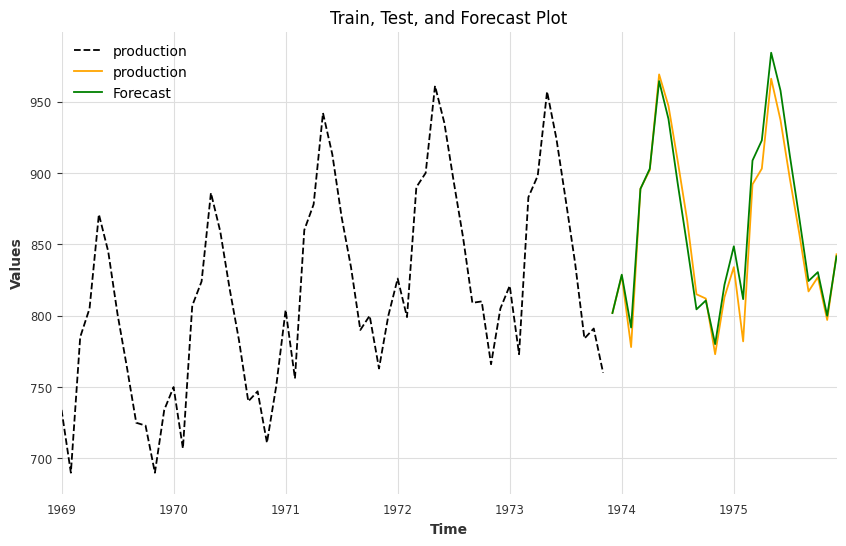

In [133]:
plot_forecast(milk_best_model, '1969', milk_train, milk_test)

The formula for simple exponential smoothing (single) for time series processes without
trend or seasonality is as follows:
        
        St = αxt + (1 − α)St−1
        Ft+1 = St

The ***ExponentialSmoothing*** class is finding the optimal value for alpha ( α ), St is the
expected (smoothed) level at the current time, 𝑡𝑡 , St−1 is the previous smoothed level value at time t − 1, and xt is the observed value at the current time, 𝑡𝑡 .

The alpha ( **α** ) parameter is the level smoothing parameter and plays a vital role in
determining whether the model should trust the past or St−1 versus the present or xt .
Hence, as α gets closer to zero, the first term, 𝛼𝛼𝑥𝑥𝑡𝑡 , gets closer to zero, and more weight is put on the past. And as α gets closer to one, then the (1 − α)St−1 term gets closer to zero and more emphasis or weight is put on the present. Some of the influencing factors
depend on how much randomness is in the system. The output value for the coefficient, α , is the weight to determine how the model uses current and past observations to forecast future events or Ft+1. 

The explanation theme is similar to the rest of the formulas, so we will not dive into every detail, but the general idea holds. 

The formula for ***Holt's*** exponential smoothing (double) incorporates the addition of the trend ( 𝑇𝑇 ) and its smoothing parameter, beta ( β ). Hence, once a trend is included, the model will output the values for both coefficients – that is, alpha and beta ( α, β ):

        𝑆𝑡 = α𝑥𝑡 + (1 − α)(𝑆𝑡−1 + 𝑇𝑡−1)

        𝑇𝑡 = β(𝑆𝑡 − 𝑆𝑡−1 ) + (1 − β)𝑇𝑡−1

        𝐹𝑡+1 = 𝑆𝑡 + 𝑇𝑡

The ***Holt-Winters*** exponential smoothing (triple) formula incorporates both trend ( 𝑇 ) and seasonality ( 𝐶 ). The following equation shows multiplicative seasonality as an example:

        𝑆𝑡 = (α𝑥𝑡/𝐶𝑡−𝐿) + (1 − α)(𝑆𝑡−1 + 𝑇𝑡−1 )
            
        𝑇𝑡 = β(𝑆𝑡 − 𝑆𝑡−1 ) + (1 − β)𝑇𝑡−1
        
        𝐶𝑡 = γ (𝑥𝑡/𝑆𝑡) + (1 − γ)𝐶𝑡−𝐿
        
        𝐹𝑡+1 = (𝑆𝑡 + 𝑇𝑡 )𝐶(𝑡+1)−𝐿

You know when using ***ExponentialSmoothing*** to find the best α, β, γ parameter values, it does so by minimizing the error rate (the sum of squared error or SSE). So, every time in the loop you were passing new parameters values (for example, damped as either True or False), the model was solving for the optimal set of values for the α, β, γ coefficients by minimizing for SSE. This can be written as follows:

        min(𝐹𝑡𝑡 − 𝑥𝑡)^2

To sum it up, exponential smoothing is a fast and effective technique for smoothing
a time series for improved analysis, dealing with outliers, data imputation, and
forecasting (prediction).

In [134]:
import darts

In [135]:
from darts.models import ExponentialSmoothing
from darts import TimeSeries

In [136]:
model = ExponentialSmoothing(seasonal_periods=12)
ts = TimeSeries.from_dataframe(milk.reset_index(),
time_col='month', value_cols='production', freq='MS')

train: 143, test: 25


<Axes: xlabel='month'>

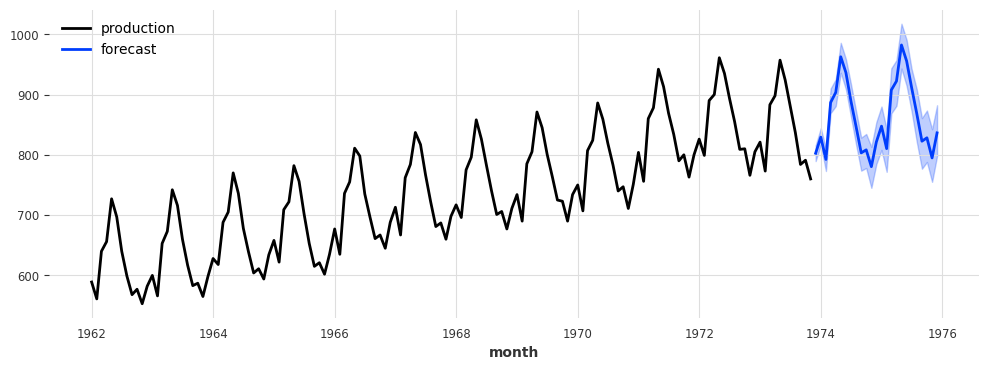

In [137]:
train, test = split_data(ts, 0.15)
model.fit(train)
forecast = model.predict(len(test), num_samples=100)
train.plot()
forecast.plot(label='forecast', low_quantile=0.05, high_quantile=0.95)

In [138]:
model.model.summary()

Dep. Variable:,endog,No. Observations:,143
Model:,ExponentialSmoothing,SSE,7265.655
Optimized:,True,AIC,593.714
Trend:,Additive,BIC,641.119
Seasonal:,Additive,AICC,599.230
Seasonal Periods:,12,Date:,"Thu, 23 Jan 2025"
Box-Cox:,False,Time:,02:39:10
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.6859243,alpha,True
smoothing_trend,6.5801e-08,beta,True


### Forecasting univariate time series data with non-seasonal ARIMA

**Autoregressive Integrated Moving Average**: AR(p), I(d), MA(q) can be defined by the p, d, and q parameters, so for a non-seasonal time series, it is described as ARIMA(p, d, q). The p and q parameters are called orders; AR of order p and MA of order q. They can also be called lags since they represent the number of periods we need to lag for. You may also come across another reference for p and q, namely ***polynomial degree***.

In [139]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

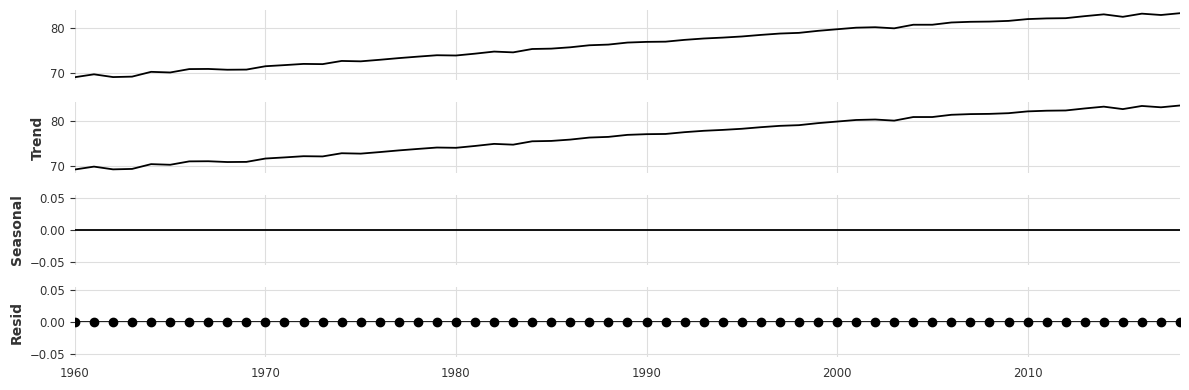

In [140]:
decomposed = seasonal_decompose(life)
decomposed.plot(); plt.show()

There is need to detrend the data first by applying first-order differencing and then for stationarity by using check_stationarity() function created earlier.

In [141]:
life_diff1 = life.diff().dropna()
check_stationarity(life_diff1)

"Stationary 	 P-value: 1.556218967600307e-14 	 lags: 1


{1.556218967600307e-14, 'Stationary'}

Now, the data is stationary. The p-value is significant, and you can reject the null hypothesis. Note that the default periods value for diff is 1. In the case of diff(1) or diff(), the lagged version is t-1 (for example, the prior month's observation).

<Axes: xlabel='year'>

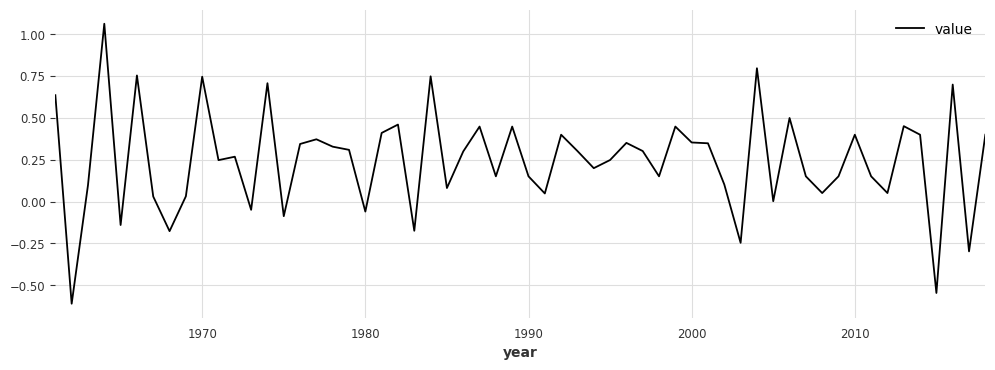

In [142]:
life_diff1.plot()

The ACF and PACF will help determine or estimate the appropriate values of p and q for the moedls AR and MA, respectively.

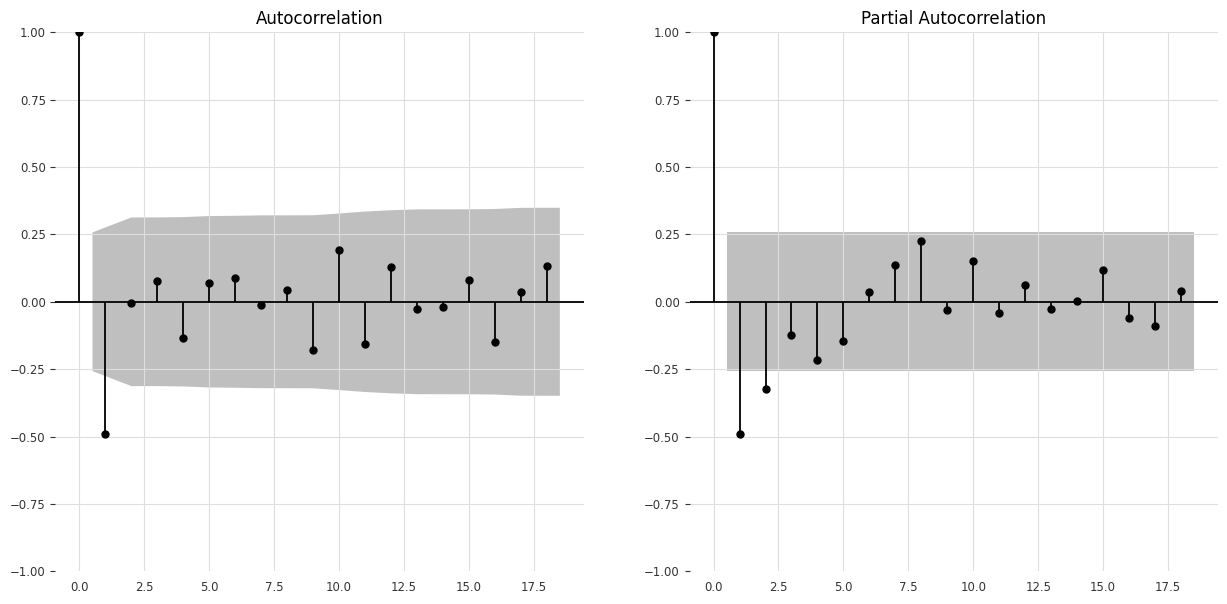

In [143]:
fig, ax = plt.subplots(1, 2, figsize=(15,7))
plot_acf(life_diff1, ax=ax[0])
plot_pacf(life_diff1, ax=ax[1])
plt.show()

We therefore train an ARIMA(0,1,1) model with p=0, i=1, and q=1 respectively.

In [144]:
model = ARIMA(life_train, order=(0,1,1))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  value   No. Observations:                   50
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -24.161
Date:                Thu, 23 Jan 2025   AIC                             52.321
Time:                        02:39:23   BIC                             56.105
Sample:                    01-01-1960   HQIC                            53.757
                         - 01-01-2009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0827      0.200      0.413      0.680      -0.310       0.475
sigma2         0.1569      0.032      4.918      0.000       0.094       0.219
===================================================================================
Ljung-Box (L1) (Q):                  12.54   Jarque-Bera (JB):                 0.56
Prob(Q):                              0.00   Prob(JB):                         0.76
Heteroskedasticity (H):               0.43   Skew:                             0.07
Prob(H) (two-sided):                  0.10   Kurtosis:                         3.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

You will need to validate the model's residuals to determine if the ARIMA model you built captured the signals in the time series. The assumption is that if the model captured all the information, the residuals from the model's prediction are random (noise) and do not follow a pattern. For example, you expect no autocorrelation in the residuals. Start by using the acorr_ljungbox test on the residuals. You should expect no autocorrelation:

In [145]:
(acorr_ljungbox(results.resid, lags=26, return_df=True) < 0.05).head()

,lb_stat,lb_pvalue
1,True,False
2,True,False
3,True,False
4,True,False
5,True,False


In [146]:
(acorr_ljungbox(results.resid, lags=26, return_df=True) < 0.05)['lb_pvalue'].sum()

0

The result shows 0, which is an aggregate of the results for the first 25 lags, indicating no autocorrelation.

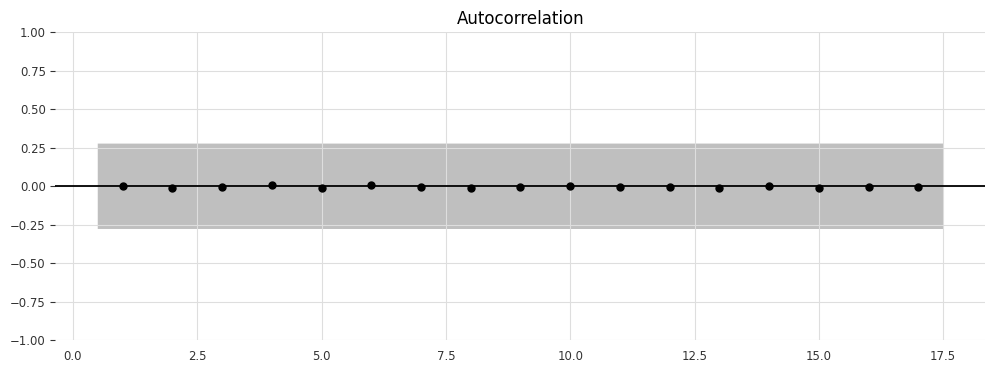

In [147]:
plot_acf(results.resid, zero=False); plt.show()

That's how we expected our collelogram to look like. The plot shows no significant lags. All the vertical lines should be closer to the zero line for all the lags. Our instance entailed 26 lags.

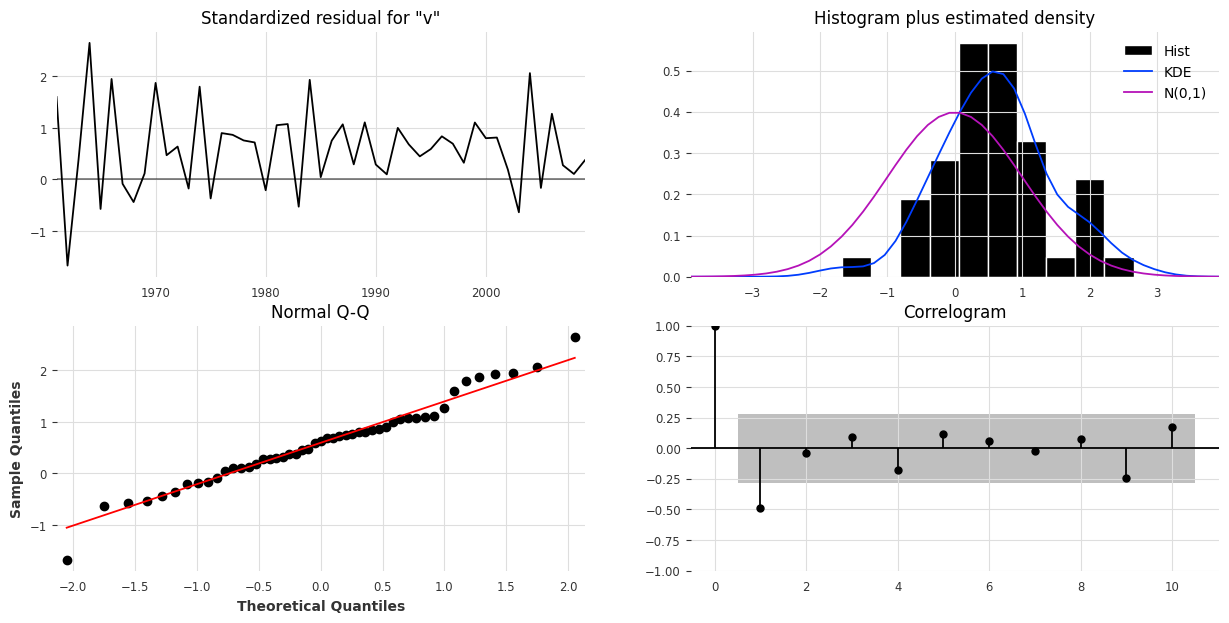

In [148]:
results.plot_diagnostics(figsize=(15,7)); plt.show()

<Axes: title={'center': 'Train, Test, and Forecast Plot'}, xlabel='Time', ylabel='Values'>

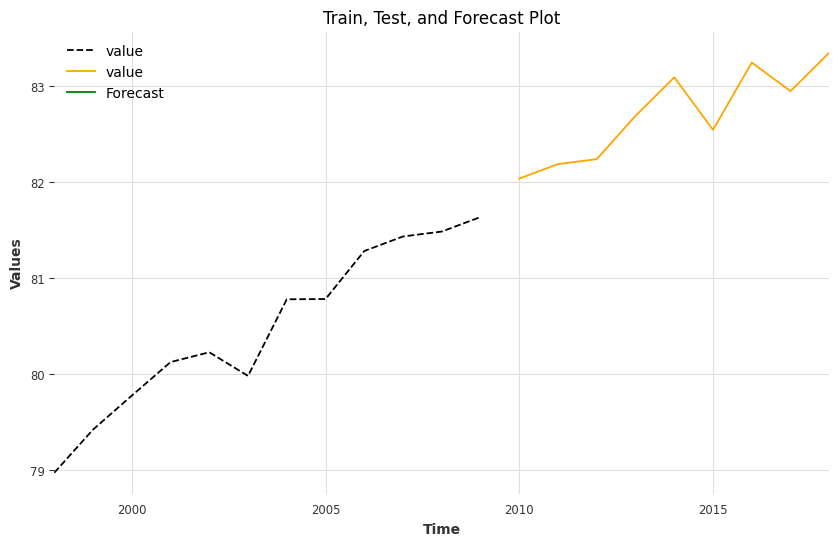

In [149]:
plot_forecast(results, '1998', life_train, life_test)

An autoregressive model or **AR**(***p***) is a linear model that uses observations from previous time steps as inputs into a regression equation to determine the predicted value of the next step. Hence, the auto part in autoregression indicates self and can be described as the regression of a variable on a past version of itself.

            𝐴R(𝑝) = y𝑡 = α + θ1y𝑡−1 + θ2 y𝑡−2 + ⋯ + θ𝑝y𝑡−𝑝 + ϵ𝑡

This is an **AR** model of order p written as **AR**(***p***). The main difference between an autoregressive and regression model is that the predicted variable is y𝑡 , which is y at the
current time, 𝑡 , and that the y𝑡−1 , y𝑡−2 , … , y𝑡−𝑝 variables are lagged (previous) versions of y. In this recipe, you used an **ARIMA**(0,1,1), which translates into an **AR**(0), indicating no autoregressive model being used. Unlike an autoregressive model that uses past values, the moving average or MA(q) uses past errors (from past estimates) to make a prediction:

            𝑀A(𝑞) = y𝑡 = β + θ1 ϵ𝑡−1 + θ2 ϵ𝑡−2 + ⋯ + θ𝑝 ϵ𝑡−𝑞 + ϵ𝑡

Combining the **AR**(***p***) and **MA**(***q***) models would produce an **ARMA**(***p***,***q***) model (autoregressive moving average). Both the **AR** and **ARMA** processes assume a stationary time series. However, suppose the time series is not stationary due to the presence of a trend. In that case, you cannot use the **AR** or **ARMA** models on non-stationary data, unless you perform some transformations, such as differencing. This was the case with the life data. 

Differencing is just subtracting a current value from its previous (lagged) version. For example, a differencing order of one (lag=1) can be written as y𝑡 − y𝑡−1 . In pandas, you used the diff method, which is set to periods=1 by default.

The **ARIMA** model improves on the **ARMA** model by adding an integrated (differencing) factor to make the time series stationary.

You leveraged both **ACF** plots and **PACF** plots to estimate the order values for the **AR** and **MA** models. The autocorrelation function measures the correlation between a current observation and its lagged version. The purpose of the **ACF** plot is to determine how reliable past observations are in making predictions. 

On the other hand, a **partial autocorrelation function** (**PACF**) is like autocorrelation but with the relationships of intervening observations removed.

One of the reasons ARIMA is popular is because it generalizes to other simpler models,
as follows:

• ARIMA(1, 0, 0) is a first-order autoregressive or AR(1) model  

• ARIMA(1, 1, 0) is a differenced first-order autoregressive model

• ARIMA(0, 0, 1) is a first-order moving average or MA(1) model

• ARIMA(1, 0, 1) is an ARMA (1,1) model

• ARIMA(0, 1, 1) is a simple exponential smoothing model

In [150]:
# Grid search of finding optimal number of lags
pv, dv, qv = [list(range(3))]*3
values = combinator([pv, dv, qv])
scores = {}

for i, (p, d, q) in enumerate(values):
    model = ARIMA(life_train, order=(p, d, q))
    results = model.fit()
    y = life_test.values.ravel()
    y_hat = results.forecast(steps=len(y))
    scores[i] = {
        'order': (p,d,q),
        'RMSPE': rmspe(y, y_hat),
        'RMSE': rmse(y, y_hat),
        'MAPE': mape(y, y_hat),
        'BIC': results.bic,
        'AICc': results.aicc,
        'model': model
    }

best_model = get_best_model(scores, 'BIC')

Best model: 8 with lowest BIC score: 13.312549149205086


In [151]:
pd.DataFrame(scores).T.sort_values(by='BIC').reset_index().head()

,index,order,RMSPE,RMSE,MAPE,BIC,AICc,model
0,8,"(0, 2, 2)",0.055949,0.463519,0.004493,13.312549,8.244401,<statsmodels.tsa.arima.model.ARIMA object at 0...
1,14,"(1, 1, 2)",0.054759,0.453643,0.004395,17.100478,10.442288,<statsmodels.tsa.arima.model.ARIMA object at 0...
2,17,"(1, 2, 2)",0.055717,0.461601,0.004468,17.161906,10.607334,<statsmodels.tsa.arima.model.ARIMA object at 0...
3,23,"(2, 1, 2)",0.054476,0.451296,0.004365,20.968975,12.905222,<statsmodels.tsa.arima.model.ARIMA object at 0...
4,26,"(2, 2, 2)",0.074461,0.617242,0.006221,23.189857,15.262423,<statsmodels.tsa.arima.model.ARIMA object at 0...


The **Akaike Information Criterion** (**AIC**) is a metric that aims to find a balance between
a model's maximum likelihood and a model's simplicity. Overly complex models can sometimes overfit, meaning they can look like they learned but once they are presented with unseen data, they perform poorly. The AIC score penalizes as the number of parameters increases since they increase complexity:

        AIC = 2𝑘 − 2 ln(𝐿∗)

Here, 2k is considered the penalty term.

The Bayesian **Information Criteria** (**BIC**) is very similar to AIC but has a higher penalty term on the model's complexity. In general, the BIC penalty term is more significant,
so it can encourage models with fewer parameters than AIC does. Therefore, if you change the sorting or evaluation criteria from AIC to BIC, you may see different results. Simpler models are preferred more with BIC:

            BIC = 𝑘 ln(𝑛) − 2 ln(𝐿∗ )

Here, 𝐿∗ is the maximum likelihood, k is the number of estimated parameters, and n is the
number of data points.

To plot a forecast using the best model:

<Axes: xlabel='year'>

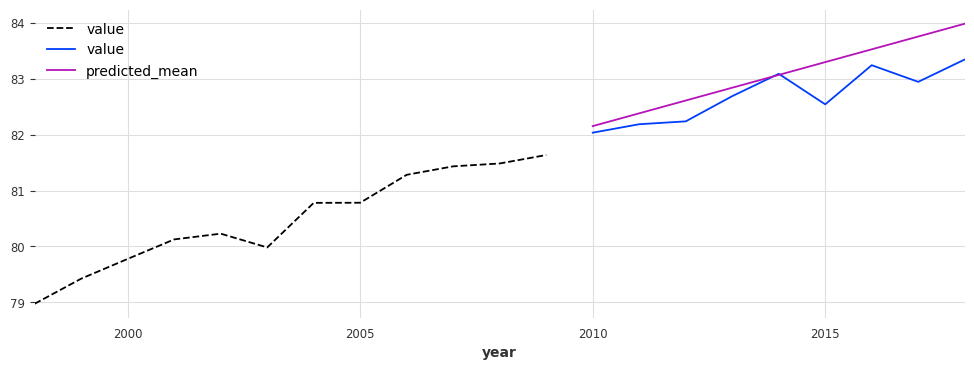

In [152]:
def plot_forecast(model, start, train, test):
    '''
    model: Fitted model object
    start: Starting position for plotting
    train: Train dataset (time series)
    test: Test dataset (time series)
    '''
    # Ensure the model is fitted
    model_fit = model.fit()

    # Generate predictions
    forecast_values = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
    forecast = pd.DataFrame(forecast_values, index=test.index)

    # Plot the train and test data
    ax = train.loc[start:].plot(style='--', label='Train Data')
    test.plot(ax=ax, label='Test Data')

    # Plot the forecast
    forecast.plot(ax=ax, style='-', label='Forecast')

    ax.legend()
    
    return ax


plot_forecast(best_model, '1998', life_train, life_test)

### Forecasting univariate time series data with seasonal ARIMA

Like an ARIMA(p, d, q), a SARIMA model also requires (p, d, q) to represent non-seasonal orders. Additionally, a SARIMA model requires the orders for the seasonal component, which is denoted as (P, D, Q, s). Combining both components, the model can be written as a SARIMA(p, d, q)(P, D, Q, s). The letters still mean the same, and the letter case indicates which component. For example, the lowercase letters represent the non-seasonal orders, while the uppercase letters represent the seasonal orders. The new parameter, s, is the number of steps per cycle – for example, s=12 for monthly data or s=4 for quarterly data.

In [153]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

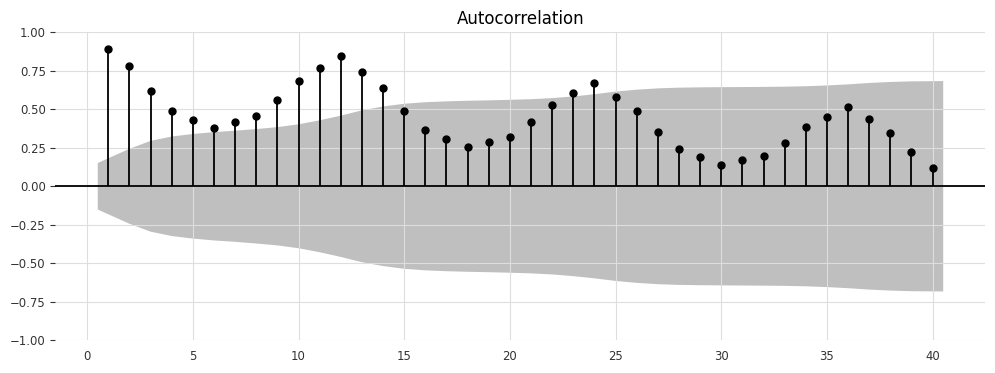

In [154]:
plot_acf(milk, lags=40, zero=False); plt.show()

This produces an ACF plot for the milk data with noticeable cyclical pattern of the spikes at lags 1,12 and 24. There is a repeating pattern after every 12 months (lags). If the pattern is not clear to see, try ACF plot after applying differencing.

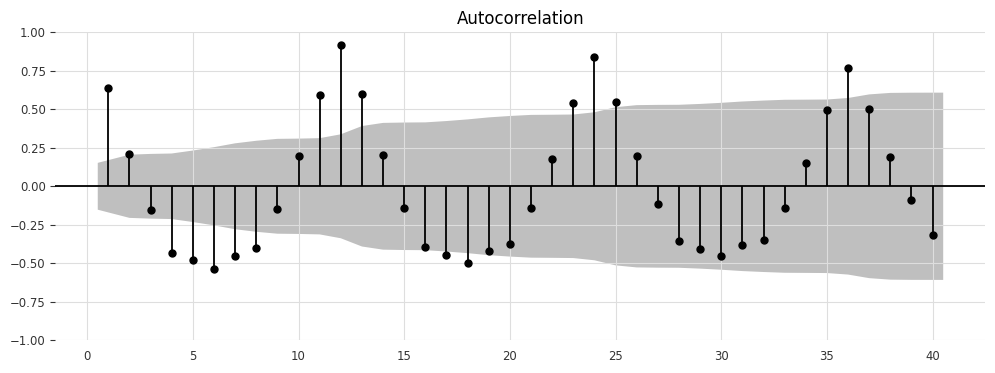

In [155]:
plot_acf(milk.diff(2).dropna(), lags=40, zero=False); plt.show()

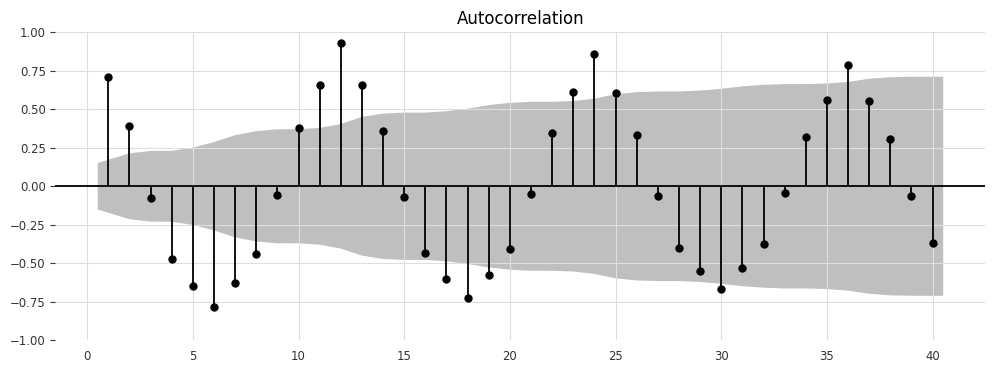

In [156]:
decomposed = seasonal_decompose(milk, period=12, model='multiplicative')
milk_seasonal = decomposed.seasonal

plot_acf(milk_seasonal, zero=False, lags=40); plt.show()

Suppose you are not sure about the values for d (non-seasonal differencing) and
D (seasonal differencing). In that case, you can use the check_stationarity
function after differencing to determine if seasonal differencing was enough or not.
In most cases, if the time series has both trend and seasonality, you may need to
difference twice. First, you perform seasonal differencing, followed by a first-order
differencing for detrending.

"Non-Stationary 	 P-value: 0.6274267086030311 	 lags: 13


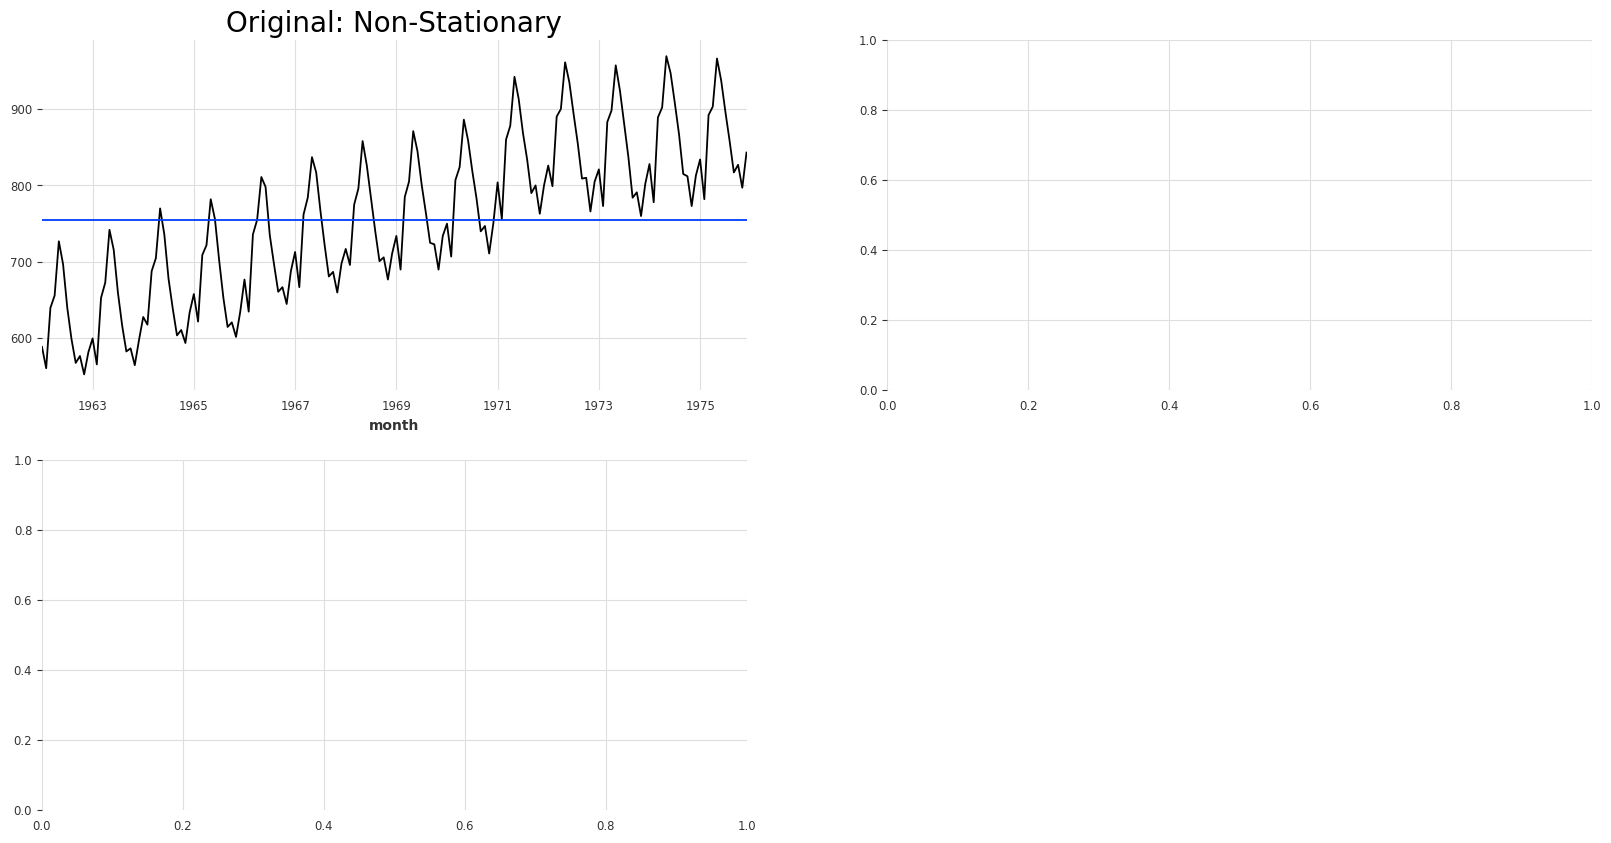

"Non-Stationary 	 P-value: 0.1607988052771125 	 lags: 12
"Stationary 	 P-value: 1.865423431878848e-05 	 lags: 11


In [157]:
milk_diff12 = milk.diff(12).dropna()
milk_diff12_1 = milk.diff(12).diff(1).dropna()
sets = [milk, milk_diff12, milk_diff12_1]
descriptions = ['Original','Deseasonalize (DIfference Once)', 'Differencing Twice']

fig, ax = plt.subplots(2, 2, figsize=(20, 10))
index, l = milk.index, milk.shape[0]

for i, (d_set, d_description) in enumerate(zip(sets, descriptions)):
    v, r = i // 2, i % 2
    outcome, p_value = check_stationarity(d_set)
    d_set.plot(ax=ax[v,r], title=f'{d_description}: {outcome}', legend=False)
    pd.Series(d_set.mean().values.tolist()*l, index=index).plot(ax=ax[v,r])
    ax[v,r].title.set_size(20)
    ax[1,1].set_visible(False)
    plt.show()

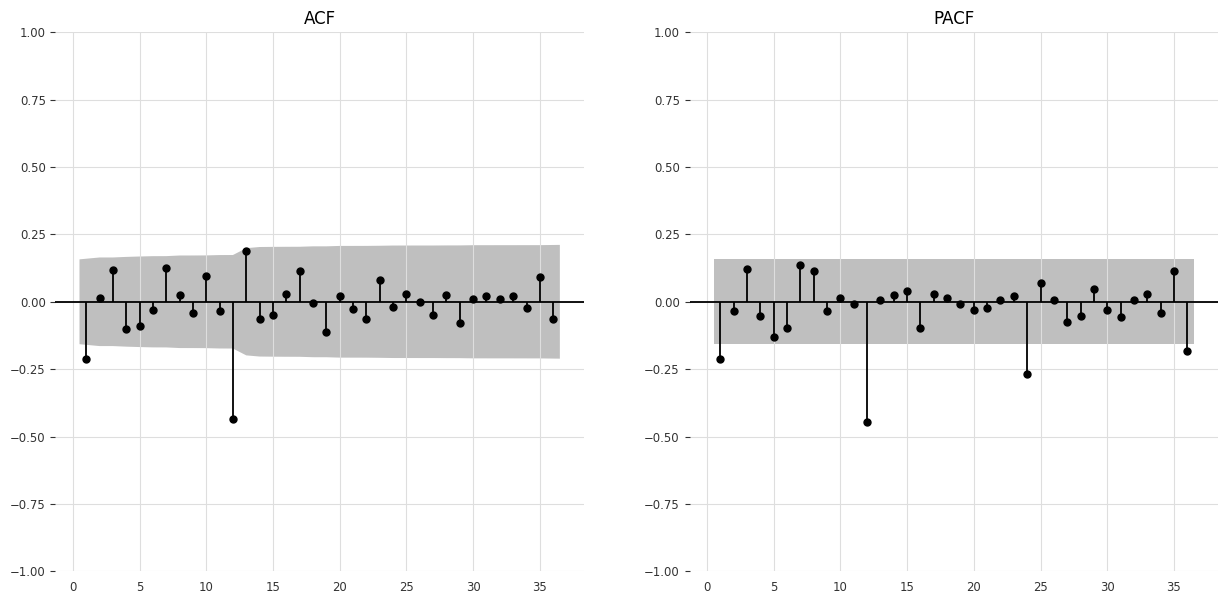

In [158]:
fig, ax = plt.subplots(1,2, figsize=(15,7))
plot_acf(milk_diff12_1, zero=False, lags=36, ax=ax[0], title=f'ACF')
plot_pacf(milk_diff12_1, zero=False, lags=36, ax=ax[1], title=f'PACF')
plt.show()

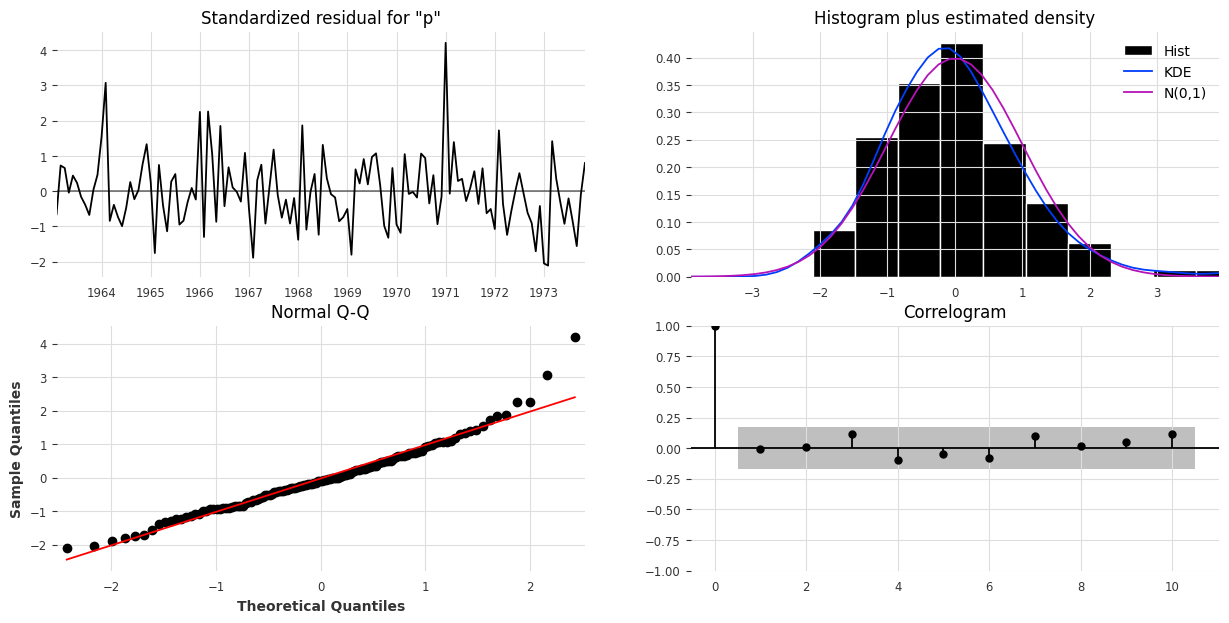

In [159]:
sarima_model = SARIMAX(milk_train, order=(0,1,1),  seasonal_order=(0,1,1,12))
model = sarima_model.fit(disp=0)

model.plot_diagnostics(figsize=(15,7)); plt.show()

In [160]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         production   No. Observations:                  143
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -448.668
Date:                            Thu, 23 Jan 2025   AIC                            903.335
Time:                                    02:41:19   BIC                            911.938
Sample:                                01-01-1962   HQIC                           906.831
                                     - 11-01-1973                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2811      0.084     -3.331      0.001      -0.446      -0.116
ma.S.L12      -0.6334      0.083     -7.653      0.000      -0.796      -0.471
sigma2        55.5239      5.753      9.650      0.000      44.247      66.800
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                35.77
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.15   Skew:                             0.82
Prob(H) (two-sided):                  0.65   Kurtosis:                         4.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.16679D+00    |proj g|=  2.99764D-02


 This problem is unconstrained.



At iterate    5    f=  3.13760D+00    |proj g|=  9.67872D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      9     11      1     0     0   5.213D-06   3.138D+00
  F =   3.1375357963596127     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


<Axes: xlabel='month'>

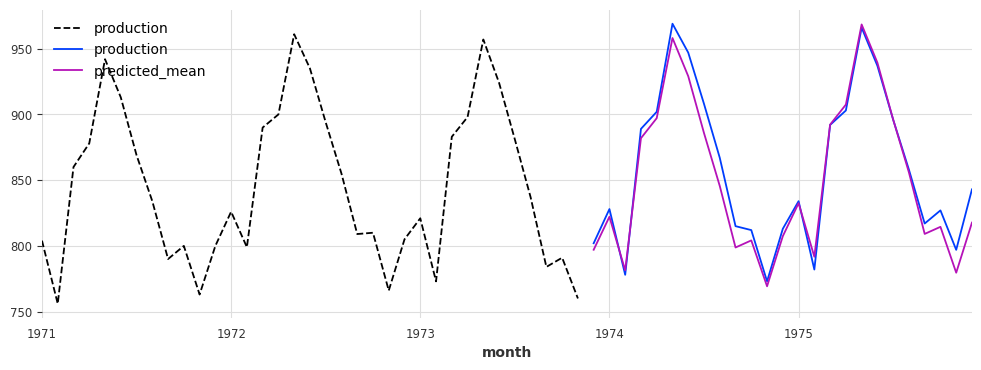

In [161]:
plot_forecast(sarima_model, '1971', milk_train, milk_test)

In [162]:
P_ns, D_ns, Q_ns = [list(range(3))]*3
P_s, D_s, Q_s = [list(range(2))]*3
vals = combinator([P_ns, D_ns, Q_ns, P_s, D_s, Q_s])
score = {}

for i, (p, d, q, P, D, Q) in enumerate(vals):
    if i%15 == 0:
        print(f'Running model #{i} using SARIMA({p},{d},{q})({P},{D},{Q},12)')

    m = SARIMAX(milk_train, order=(p,d,q), seasonal_order=(P, D, Q, 12), enforce_stationarity=False)
    res = m.fit(disp=0)
    y = milk_test.values.ravel()
    y_hat = res.forecast(steps=len(y))
    score[i] = {
        'non-seasonal order': (p,d,q),
        'seasonal order': (P, D, Q),
        'AIC':res.aic,
        'AICc': res.aicc,
        'BIC': res.bic,
        'RMSPE': rmspe(y, y_hat),
        'RMSE' : rmse(y, y_hat),
        'MAPE' : mape(y, y_hat),
        'model': res
    }

Running model #0 using SARIMA(0,0,0)(0,0,0,12)
Running model #15 using SARIMA(0,0,1)(1,1,1,12)
Running model #30 using SARIMA(0,1,0)(1,1,0,12)
Running model #45 using SARIMA(0,1,2)(1,0,1,12)
Running model #60 using SARIMA(0,2,1)(1,0,0,12)
Running model #75 using SARIMA(1,0,0)(0,1,1,12)
Running model #90 using SARIMA(1,0,2)(0,1,0,12)
Running model #105 using SARIMA(1,1,1)(0,0,1,12)
Running model #120 using SARIMA(1,2,0)(0,0,0,12)
Running model #135 using SARIMA(1,2,1)(1,1,1,12)
Running model #150 using SARIMA(2,0,0)(1,1,0,12)
Running model #165 using SARIMA(2,0,2)(1,0,1,12)
Running model #180 using SARIMA(2,1,1)(1,0,0,12)
Running model #195 using SARIMA(2,2,0)(0,1,1,12)
Running model #210 using SARIMA(2,2,2)(0,1,0,12)


Notice the enforce_stationarity=False parameter to avoid a LinAlgError that may occur when running a naive grid search.

In [163]:
best_arima_model = get_best_model(score, 'AIC')

Best model: 211 with lowest AIC score: 795.4217652246253


<Axes: xlabel='month'>

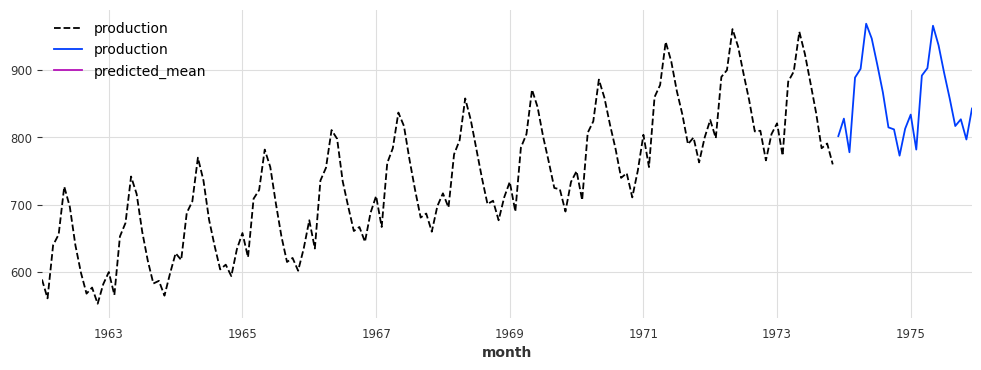

In [164]:
plot_forecast(best_model, '1962', milk_train, milk_test)

You can also store the results from training the models in a tabular format using the
following command:

In [165]:
pd.DataFrame(score).T.sort_values(by='AIC').reset_index().head()

,index,non-seasonal order,seasonal order,AIC,AICc,BIC,RMSPE,RMSE,MAPE,model
0,211,"(2, 2, 2)","(0, 1, 1)",795.421765,796.206812,811.838956,0.17819,15.135855,0.014454,<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
1,67,"(0, 2, 2)","(0, 1, 1)",795.51592,795.882892,806.460713,0.32824,27.79722,0.028315,<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
2,43,"(0, 1, 2)","(0, 1, 1)",796.763902,797.127539,807.743631,0.134089,11.487077,0.010387,<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
3,191,"(2, 1, 2)","(1, 1, 1)",796.867371,797.9141,816.081896,0.112242,9.645432,0.00907,<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
4,187,"(2, 1, 2)","(0, 1, 1)",796.876071,797.653849,813.345664,0.12826,10.998608,0.010075,<statsmodels.tsa.statespace.sarimax.SARIMAXRes...


In [166]:
pd.DataFrame(score).T.sort_values(by='AIC').reset_index().shape

(216, 10)